### Data Preprocessing

In [1]:
import pandas as pd

SDI = ['AGE_DIV','RACE_DIV','EDU_DIV','INC_DIV']
SVI = ['EPL_POV150','EPL_UNEMP','EPL_HBURD','EPL_NOHSDP','EPL_UNINSUR',
       'EPL_AGE65','EPL_AGE17','EPL_DISABL','EPL_SNGPNT','EPL_LIMENG',
       'EPL_MINRTY',
       'EPL_MUNIT','EPL_MOBILE','EPL_CROWD','EPL_NOVEH','EPL_GROUPQ']

df = pd.read_csv('SVI_SDI_RI_Dataset_v1.csv')
df = df[['Age','Race','Education','Income'] + SVI + ['pre_disaster','short_term','long_term']]
df.columns = SDI + SVI + ['PRE_EFFECT','SHORT_IMPACT','LONG_IMPACT']

dic = {0:1, 1:2, 2:0}
df['LONG_IMPACT'] = df['LONG_IMPACT'].apply(lambda x: dic[x])

print(df['PRE_EFFECT'].value_counts())
print(df['LONG_IMPACT'].value_counts())

PRE_EFFECT
0    826
1    262
Name: count, dtype: int64
LONG_IMPACT
0    829
2    222
1     37
Name: count, dtype: int64


### Short-term Disaster Impact Prediction

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

X = df[SDI + SVI].values
y = df['SHORT_IMPACT'].values

model = Ridge(random_state=100)
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')

for fold, score in enumerate(scores, 1):
    print(f'Fold {fold}: MSE = {-score:.3f}')
print(f'Mean MSE: {np.mean(-scores):.3f}')

Fold 1: MSE = 0.054
Fold 2: MSE = 0.059
Fold 3: MSE = 0.057
Fold 4: MSE = 0.061
Fold 5: MSE = 0.057
Fold 6: MSE = 0.062
Fold 7: MSE = 0.063
Fold 8: MSE = 0.073
Fold 9: MSE = 0.066
Fold 10: MSE = 0.057
Mean MSE: 0.061


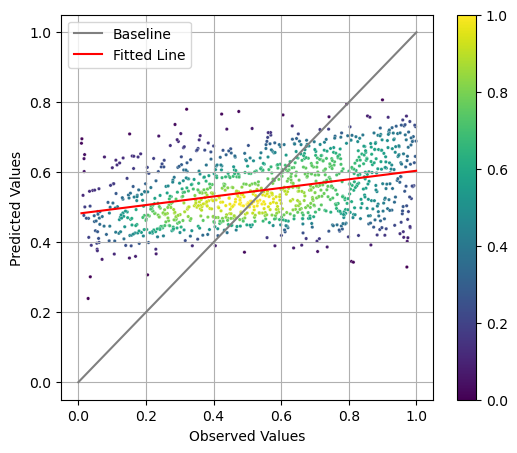

In [3]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

model = Ridge(random_state=100)
model.fit(X, y)
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color='grey', label='Baseline')
ax.plot(np.unique(y), np.poly1d(np.polyfit(y,y_pred,1))(np.unique(y)), color='r', label='Fitted Line')
ax.set(xlabel='Observed Values', ylabel='Predicted Values')
ax.legend()
ax.grid()

kernel = stats.gaussian_kde(np.vstack([y, y_pred]))(np.vstack([y, y_pred]))
sns.scatterplot(x=y, y=y_pred, c=kernel, s=6, cmap='viridis', ax=ax)
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax)

#plt.savefig('KDE_Plot.svg', dpi=600, bbox_inches='tight')
plt.show()

### Pre-disaster Effect Prediction

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, recall_score

X = df[SDI + SVI].values
y = df['PRE_EFFECT'].values

model = RidgeClassifier(random_state=100)
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
scorer = make_scorer(recall_score, average='weighted', labels=[0,1]) #labels=[0,1]
scores = cross_val_score(model, X, y, cv=kfold, scoring=scorer) #scoring='Accuracy'

for fold, score in enumerate(scores, 1):
    print(f'Fold {fold}: Score = {score:.3f}')
print(f'Mean Score: {np.mean(scores):.3f}')

Fold 1: Score = 0.771
Fold 2: Score = 0.734
Fold 3: Score = 0.697
Fold 4: Score = 0.734
Fold 5: Score = 0.771
Fold 6: Score = 0.826
Fold 7: Score = 0.807
Fold 8: Score = 0.789
Fold 9: Score = 0.722
Fold 10: Score = 0.694
Mean Score: 0.755


### Long-term Disaster Impact Prediction

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, recall_score

X = df[SDI + SVI].values
y = df['LONG_IMPACT'].values

model = RidgeClassifier(random_state=100)
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
scorer = make_scorer(recall_score, average='weighted', labels=[0,1,2]) #labels=[0,1,2]
scores = cross_val_score(model, X, y, cv=kfold, scoring=scorer) #scoring='Accuracy'

for fold, score in enumerate(scores, 1):
    print(f'Fold {fold}: Score = {score:.3f}')
print(f'Mean Score: {np.mean(scores):.3f}')

Fold 1: Score = 0.789
Fold 2: Score = 0.734
Fold 3: Score = 0.743
Fold 4: Score = 0.771
Fold 5: Score = 0.716
Fold 6: Score = 0.798
Fold 7: Score = 0.771
Fold 8: Score = 0.780
Fold 9: Score = 0.741
Fold 10: Score = 0.769
Mean Score: 0.761
